In [1]:
from customSRT import PopulationSpaceSRT
from lbmpy import LBStencil, Stencil, LBMOptimisation, create_lb_update_rule

import sympy
import pystencils as ps

sympy.init_printing(use_latex="mathjax")

In [2]:
stencil = LBStencil(Stencil.D2Q9)
srt_method = PopulationSpaceSRT(stencil, sympy.Symbol("omega"), method="onsager")
srt_method.method_type

'onsager'

## Domain and Arrays

In [3]:
# grid points
N = Ny = Nx = 256
# data handler (NxN periodic grid laid out in Structure of Arrays (?) format)
dh = ps.create_data_handling(
        domain_size=(Ny, Nx),
        periodicity=(True, True),
        default_layout="fzyx",
)

In [4]:
# create population arrays
f = dh.add_array(name="f", values_per_cell=stencil.Q)
f_tmp = dh.add_array(name="f_tmp", values_per_cell=stencil.Q)

# create field arrays
rho = dh.add_array(name="rho", values_per_cell=1)
u = dh.add_array(name="u", values_per_cell=stencil.D)

## Stream-Collide Kernel

In [5]:
lbm_opt = LBMOptimisation(
    symbolic_field=f,
    symbolic_temporary_field=f_tmp
)

output_fields = dict({"density": rho, "velocity": u})

update_rule = create_lb_update_rule(
    lb_method = srt_method,
    lbm_optimisation=lbm_opt,
    output = output_fields
)

update_rule = ps.simp.add_subexpressions_for_divisions(update_rule)

In [6]:
# update_rule

In [7]:
# create stream-collide kernel
ker_stream_collide = ps.create_kernel(update_rule).compile()

In [8]:
# ps.show_code(ker_stream_collide)

## Initialization Kernel

In [9]:
from lbmpy.macroscopic_value_kernels import macroscopic_values_setter


ac_init = macroscopic_values_setter(
    lb_method=srt_method,
    density=rho.center,       # rho_(0,0)
    velocity=u.center_vector, # \vec{u}_(0,0)
    pdfs=f,
    set_pre_collision_pdfs=True
)

In [10]:
# ac_init

In [11]:
ker_init = ps.create_kernel(ac_init).compile()

In [23]:
ps.show_code(ker_init)

FUNC_PREFIX void kernel(double * RESTRICT  _data_f, double * RESTRICT const _data_rho, double * RESTRICT const _data_u)
{
   for (int64_t ctr_1 = 1; ctr_1 < 257; ctr_1 += 1)
   {
      for (int64_t ctr_0 = 1; ctr_0 < 257; ctr_0 += 1)
      {
         _data_f[ctr_0 + 258*ctr_1] = 0.44444444444444442*_data_rho[ctr_0 + 258*ctr_1]*(-1.5*(_data_u[ctr_0 + 258*ctr_1 + 66564]*_data_u[ctr_0 + 258*ctr_1 + 66564]) - 1.5*(_data_u[ctr_0 + 258*ctr_1]*_data_u[ctr_0 + 258*ctr_1]) + 1.0);
         _data_f[ctr_0 + 258*ctr_1 + 66306] = 0.1111111111111111*_data_rho[ctr_0 + 258*ctr_1]*(-1.5*(_data_u[ctr_0 + 258*ctr_1]*_data_u[ctr_0 + 258*ctr_1]) + 1.0 + 3.0*_data_u[ctr_0 + 258*ctr_1 + 66564] + 3.0*(_data_u[ctr_0 + 258*ctr_1 + 66564]*_data_u[ctr_0 + 258*ctr_1 + 66564]));
         _data_f[ctr_0 + 258*ctr_1 + 133386] = 0.1111111111111111*_data_rho[ctr_0 + 258*ctr_1]*(-1.5*(_data_u[ctr_0 + 258*ctr_1]*_data_u[ctr_0 + 258*ctr_1]) - 3.0*_data_u[ctr_0 + 258*ctr_1 + 66564] + 1.0 + 3.0*(_data_u[ctr_0 + 258*ctr_1 + 66564]*_data_u[ctr_0 + 258*ctr_1 + 66564]));
         _data_f[ctr_0 + 258*ctr_1 + 199693] = 0.1111111111111111*_data_rho[ctr_0 + 258*ctr_1]*(-1.5*(_data_u[ctr_0 + 258*ctr_1 + 66564]*_data_u[ctr_0 + 258*ctr_1 + 66564]) - 3.0*_data_u[ctr_0 + 258*ctr_1] + 1.0 + 3.0*(_data_u[ctr_0 + 258*ctr_1]*_data_u[ctr_0 + 258*ctr_1]));
         _data_f[ctr_0 + 258*ctr_1 + 266255] = 0.1111111111111111*_data_rho[ctr_0 + 258*ctr_1]*(-1.5*(_data_u[ctr_0 + 258*ctr_1 + 66564]*_data_u[ctr_0 + 258*ctr_1 + 66564]) + 1.0 + 3.0*_data_u[ctr_0 + 258*ctr_1] + 3.0*(_data_u[ctr_0 + 258*ctr_1]*_data_u[ctr_0 + 258*ctr_1]));
         _data_f[ctr_0 + 258*ctr_1 + 332563] = 0.027777777777777776*_data_rho[ctr_0 + 258*ctr_1]*(-1.5*(_data_u[ctr_0 + 258*ctr_1 + 66564]*_data_u[ctr_0 + 258*ctr_1 + 66564]) - 1.5*(_data_u[ctr_0 + 258*ctr_1]*_data_u[ctr_0 + 258*ctr_1]) - 3.0*_data_u[ctr_0 + 258*ctr_1] + 1.0 + 3.0*_data_u[ctr_0 + 258*ctr_1 + 66564] + 4.5*((_data_u[ctr_0 + 258*ctr_1 + 66564] - _data_u[ctr_0 + 258*ctr_1])*(_data_u[ctr_0 + 258*ctr_1 + 66564] - _data_u[ctr_0 + 258*ctr_1])));
         _data_f[ctr_0 + 258*ctr_1 + 399125] = 0.027777777777777776*_data_rho[ctr_0 + 258*ctr_1]*(-1.5*(_data_u[ctr_0 + 258*ctr_1 + 66564]*_data_u[ctr_0 + 258*ctr_1 + 66564]) - 1.5*(_data_u[ctr_0 + 258*ctr_1]*_data_u[ctr_0 + 258*ctr_1]) + 1.0 + 3.0*_data_u[ctr_0 + 258*ctr_1 + 66564] + 3.0*_data_u[ctr_0 + 258*ctr_1] + 4.5*((_data_u[ctr_0 + 258*ctr_1 + 66564] + _data_u[ctr_0 + 258*ctr_1])*(_data_u[ctr_0 + 258*ctr_1 + 66564] + _data_u[ctr_0 + 258*ctr_1])));
         _data_f[ctr_0 + 258*ctr_1 + 466207] = 0.027777777777777776*_data_rho[ctr_0 + 258*ctr_1]*(-1.5*(_data_u[ctr_0 + 258*ctr_1 + 66564]*_data_u[ctr_0 + 258*ctr_1 + 66564]) - 1.5*(_data_u[ctr_0 + 258*ctr_1]*_data_u[ctr_0 + 258*ctr_1]) - 3.0*_data_u[ctr_0 + 258*ctr_1 + 66564] - 3.0*_data_u[ctr_0 + 258*ctr_1] + 1.0 + 4.5*((-_data_u[ctr_0 + 258*ctr_1 + 66564] - _data_u[ctr_0 + 258*ctr_1])*(-_data_u[ctr_0 + 258*ctr_1 + 66564] - _data_u[ctr_0 + 258*ctr_1])));
         _data_f[ctr_0 + 258*ctr_1 + 532769] = 0.027777777777777776*_data_rho[ctr_0 + 258*ctr_1]*(-1.5*(_data_u[ctr_0 + 258*ctr_1 + 66564]*_data_u[ctr_0 + 258*ctr_1 + 66564]) - 1.5*(_data_u[ctr_0 + 258*ctr_1]*_data_u[ctr_0 + 258*ctr_1]) - 3.0*_data_u[ctr_0 + 258*ctr_1 + 66564] + 1.0 + 3.0*_data_u[ctr_0 + 258*ctr_1] + 4.5*((-_data_u[ctr_0 + 258*ctr_1 + 66564] + _data_u[ctr_0 + 258*ctr_1])*(-_data_u[ctr_0 + 258*ctr_1 + 66564] + _data_u[ctr_0 + 258*ctr_1])));
      }
   }
}

## Initial state

\begin{align}
    \rho &= 1 \\
    u_x
    &=
    \begin{cases}
        u_0 \tanh \left[ \kappa \left( \frac{y}{N} - \frac{1}{4} \right)\right], \, y \leq \frac{N}{2} \\
        u_0 \tanh \left[ \kappa \left( \frac{1}{4} - \frac{y}{N} \right)\right], \, y > \frac{N}{2}
    \end{cases}\\
    u_y
    &=
    \delta u_0 \sin \left[2\pi\left( \frac{x}{N} + \frac{1}{4} \right)\right]
\end{align}


In [13]:
# Parameters for the mixing layer problem
kappa = 80    # shear layer width
u0 = 0.04     # velocity scale
delta = 0.05  # perturbation parameter

In [14]:
# Initialize the density and velocity fields to unity and zero
dh.fill(rho.name, 1.0)
dh.fill(u.name, 0.0)

In [15]:
# initialize the velocity field
import numpy
_x = numpy.linspace(0, 1, Nx)
_y = numpy.linspace(0, 1, Ny)

for y in range(Ny):
    dh.cpu_arrays[u.name][1:-1, 1+y, 1] = delta * numpy.sin(2*numpy.pi*(_x + 0.25))

tmp = numpy.zeros_like(_y)
tmp[:Ny//2] = numpy.tanh(kappa * (_y[:Ny//2] - 0.25))
tmp[Ny//2:] = numpy.tanh(kappa * (0.75 - _y[Ny//2:]))

for x in range(Nx):
    dh.cpu_arrays[u.name][1+x, 1:-1, 0] = tmp

dh.cpu_arrays[u.name] *= u0

# run the initalization kernel
dh.run_kernel(ker_init)

In [16]:
# create a method for visualizing the vorticity
from postprocess import get_vorticity
import matplotlib.pyplot as plot

def plot_vorticity(velocity):
    velx, vely = velocity.transpose()
    X, Y = numpy.meshgrid(_x, _y)

    vorticity = get_vorticity(
        u = velx, v = vely,
        nx = Nx, ny = Ny
    )

    normalized_vorticity = vorticity / numpy.max(vorticity)
    vorticity_contours = plot.contourf(X, Y, normalized_vorticity, levels=50, vmin=-1, vmax=1)

    colorbar = plot.colorbar(vorticity_contours)
    colorbar.set_ticks([-1.0, -0.5, 0.0, 0.5, 1.0])

/home/anirudh/anirudh/research/dev/erlangen/.pystencils2.0-dev/lib/python3.10/site-packages/numpy/_core/getlimits.py:558: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/anirudh/anirudh/research/dev/erlangen/.pystencils2.0-dev/lib/python3.10/site-packages/numpy/_core/getlimits.py:90: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/anirudh/anirudh/research/dev/erlangen/.pystencils2.0-dev/lib/python3.10/site-packages/numpy/_core/getlimits.py:558: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/anirudh/anirudh/research/dev/erlangen/.pystencils2.0-dev/lib/python3.10/site-packages/numpy/_core/getlimits.py:90: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type 

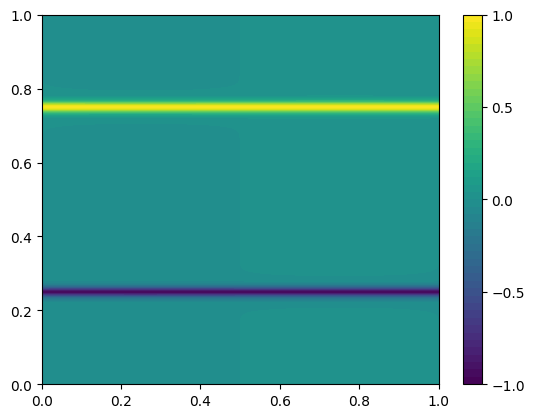

In [17]:
# visualize the initial Vorticity field
u_initial = dh.gather_array(u.name)
plot_vorticity(u_initial)

In [18]:
# method to get relaxation frequency from Reynolds number
def get_BGK_relaxation_frequency_from_Re(Re, theta=1/3):
    nu = ( u0 * N ) / Re
    tau = nu / theta
    beta = 1/(2*tau + 1)
    return 2*beta

## Integration Loop

In [19]:
# global synchronization function
gl_sync = dh.synchronization_function(f.name)

def step():
    dh.run_kernel(
        kernel_function=ker_stream_collide,
        omega = get_BGK_relaxation_frequency_from_Re(Re=30000)
    )

    dh.swap(f.name, f_tmp.name)
    gl_sync()

def loop(n):
    for _ in range(n):
        step()

## Simulation Run

In [20]:
# characteristic time
t0 = int(N/u0)
t0

6400

In [21]:
loop(t0)

256x256 grid points


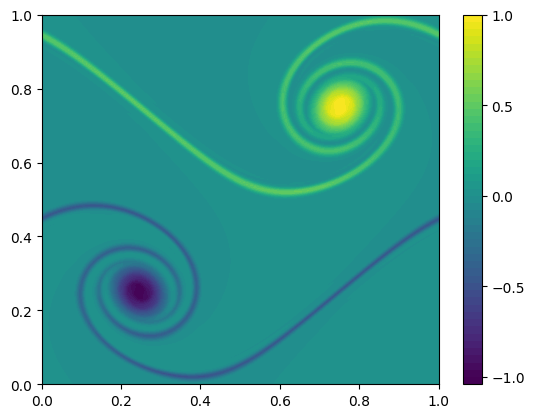

In [22]:
# visualize the Vorticity Distribution
u_final = dh.gather_array(u.name)
print(f"{N}x{N} grid points")
plot_vorticity(u_final)